# Tutorial 01: Feature Extraction and Dataset Creation

Welcome to the BioAcoustica tutorial series. In this part, we'll learn how to use a **YAML configuration** to handle species-specific parameters and generate a dataset using a **strict training file list**.

## 1. Setup and Imports

In [1]:
import os
import sys
import yaml
import numpy as np

# Add src to path
sys.path.append(os.path.abspath('../../src'))

from bioacoustica.data.preprocessor import Preprocessor
print("BioAcoustica modules loaded.")

BioAcoustica modules loaded.


## 2. Load Configuration

Instead of hardcoding values, we load them from a YAML file. This ensures consistency between training and inference.

In [2]:
CONFIG_PATH = "../../configs/gibbon.yaml"

with open(CONFIG_PATH, "r") as f:
    config = yaml.safe_load(f)

print(f"Loaded config for: {config['species_name']}")

Loaded config for: gibbon


## 3. Initialize Preprocessor

We pass the parameters from the config directly to the `Preprocessor`. Note how we use the `spectrogram` settings from the YAML.

In [3]:
AUDIO_DIR = "../../data/raw/audio"
ANNOTATIONS_DIR = "../../data/raw/annotations"
OUTPUT_DIR = "../../data/processed"

preprocessor = Preprocessor(
    audio_dir=AUDIO_DIR,
    annotations_dir=ANNOTATIONS_DIR,
    output_dir=OUTPUT_DIR,
    lowpass_cutoff=config['audio']['lowpass_cutoff'],
    downsample_rate=config['audio']['sample_rate'],
    segment_duration=config['audio']['segment_duration'],
    n_fft=config['spectrogram']['n_fft'],
    hop_length=config['spectrogram']['hop_length'],
    n_mels=config['spectrogram']['n_mels'],
    f_min=config['spectrogram'].get('f_min', 0),
    f_max=config['spectrogram']['f_max']
)
print("Preprocessor initialized.")

Preprocessor initialized.


## 4. Process and Save Training Dataset

To avoid data overlap, we use `TrainingFiles.txt` to select only the files intended for training.

In [4]:
TRAIN_LIST = "../../data/metadata/TrainingFiles.txt"

if os.path.exists(TRAIN_LIST):
    with open(TRAIN_LIST, "r") as f:
        files = [line.strip() for line in f if line.strip()]

    print(f"Processing {len(files)} training files...")
    X, Y = preprocessor.create_dataset_from_files(
        file_list=files,
        file_type="svl",
        background_classes=[config['classes'].get('absence', 'noise')],
        verbose=True
    )

    preprocessor.save_dataset(X, Y)
    print(f"\nSuccess! Training dataset saved with {len(X)} samples.")
else:
    print(f"Error: Training list not found at {TRAIN_LIST}")

Processing 10 training files...


Processing files:   0%|          | 0/10 [00:00<?, ?it/s]

Processing: HGSM3AB_0+1_20160303_060100


Processing files:  10%|█         | 1/10 [00:06<00:54,  6.09s/it]

Processing: HGSM3AB_0+1_20160305_055900


...

Processing: HGSM3C_0+1_20150807_052200


Processing files:  90%|█████████ | 9/10 [00:45<00:03,  3.74s/it]

Processing: HGSM3C_0+1_20150812_052300


Processing files: 100%|██████████| 10/10 [00:49<00:00,  4.98s/it]



Success! Training dataset saved with 3356 samples.


In [5]:
X.shape

(3356, 128, 126)

In [12]:
import matplotlib.pyplot as plt
# create function to plot random examples of spectrograms from dataset
import random
import matplotlib.pyplot as plt
def plot_random_spec_from_dataset(X, Y, num_examples: int = 5) -> None:
    indices = random.sample(range(X.shape[0]), num_examples)
    plt.figure(figsize=(5, 3 * num_examples))
    for i, idx in enumerate(indices):
        plt.subplot(num_examples, 1, i + 1)
        plt.imshow(X[idx], aspect='auto', origin='lower', cmap='magma')
        plt.title(f"Label: {Y[idx]}")
        plt.colorbar(format='%+2.0f dB')
    plt.tight_layout()
    plt.show()

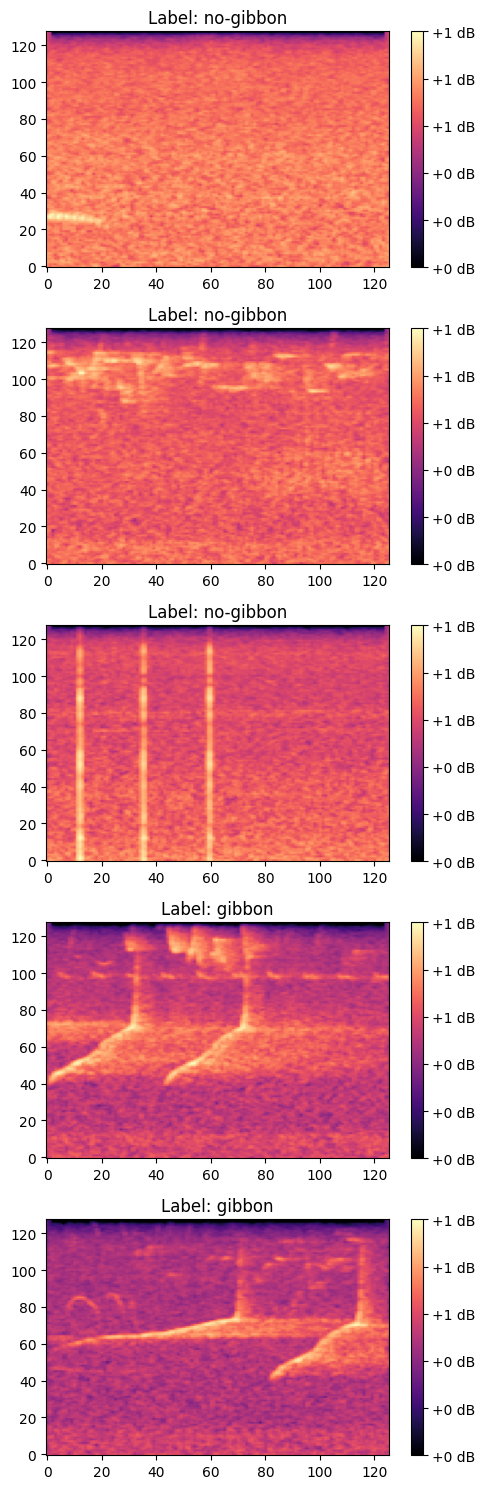

In [14]:
plot_random_spec_from_dataset(X, Y, num_examples=5)